In [ ]:
from google.colab import files #dosyamızı yükledik
uploaded=files.upload()

Saving diabetes.csv to diabetes (1).csv


In [ ]:
import pandas as pd #kütüphanelerimizi tanımladık
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split,cross_validate
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,roc_auc_score,confusion_matrix,classification_report,RocCurveDisplay


In [ ]:
def outlier_thresholds(df,col,q1=0.05,q3=0.95): #aykırı değreleri bulmayı sağlar
 q1_val=df[col].quantile(q1)
 q3_val=df[col].quantile(q3)
 iqr=q3_val-q1_val
 low_limit=q1_val-1.5*iqr
 up_limit=q3_val+1.5*iqr
 return low_limit,up_limit

In [ ]:
def replace_with_thresholds(df,col):
 low,up=outlier_thresholds(df,col)
 df[col]=np.where(df[col]<low,low,np.where(df[col]>up,up,df[col]))


In [ ]:
def plot_confusion_matrix(y_true,y_pred):
  acc=round(accuarcy_Score(y_true,y_pred),2)
  cm=confusion_matrix(y_true,y_pred)
  sns.heatmap(cm,annot=True,fmt="d")#veriyi renklerle görselleştirme
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(f"Accuarcy:{acc}")
  plt.show()

In [ ]:
#Veri Yükleme ve ilk inceleme
df=pd.read_csv(r"diabetes.csv")

In [ ]:
target="Outcome" #hedef="çıktı"
features=[col for col in df.columns if col!=target]


In [ ]:
#Eksik ve Aykırı Değer işleme
for col in features:
  replace_with_thresholds(df,col)

In [ ]:
#ölçekleme
scaler=RobustScaler()
df[features]=scaler.fit_transform(df[features])

In [ ]:
#Modelleme
X=df[features]
Y=df[target]

In [ ]:
log_model=LogisticRegression().fit(X,Y)
Y_pred=log_model.predict(X)
Y_prob=log_model.predict_proba(X)[:,1]

In [ ]:
#Başarı Değerlendirmesi("TÜM VERİ SETİ İLE")
print("Training Classification Report:\n",classification_report(Y,Y_pred))
plot_confusion_matrix(Y,Y_pred)
print("ROC AUC Score(Train):",roc_auc_score(Y,Y_pred))




Training Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.89      0.84       500
           1       0.74      0.58      0.65       268

    accuracy                           0.78       768
   macro avg       0.77      0.74      0.75       768
weighted avg       0.78      0.78      0.78       768



NameError: name 'accuarcy_Score' is not defined

In [ ]:
#Holdout Doğrulama
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=17)



In [ ]:
Y_pred=log_model.predict(X_test)
Y_prob=log_model.predict_proba(X_test)[:,1]

In [ ]:
print("Holdout Classification Report:\n",classification_report((Y_test),(Y_pred)))

Holdout Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.92      0.84        97
           1       0.80      0.56      0.66        57

    accuracy                           0.79       154
   macro avg       0.79      0.74      0.75       154
weighted avg       0.79      0.79      0.78       154



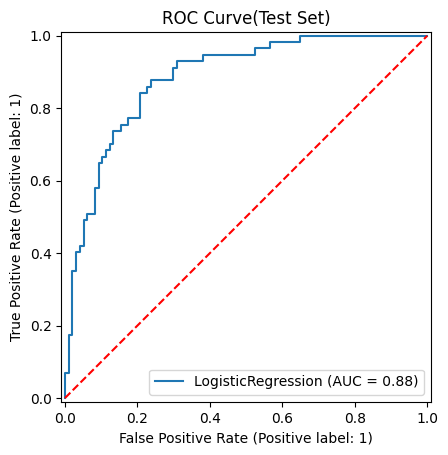

ROC AUC Score (Test): 0.8837041056248869


In [ ]:
RocCurveDisplay.from_estimator(log_model,X_test,Y_test)
plt.title("ROC Curve(Test Set)")
plt.plot([0,1],[0,1],"r--")
plt.show()
print("ROC AUC Score (Test):",roc_auc_score(Y_test,Y_prob))

In [ ]:
#Fold Cross Validation
cv_results=cross_validate(log_model,X,Y,cv=10,
scoring=["accuracy","precision","recall","f1","roc_auc"]                          )

In [ ]:
print("CV Accuracy:",cv_results["test_accuracy"].mean())
print("CV Precision:",cv_results["test_precision"].mean())
print("CV Recall:",cv_results["test_recall"].mean())
print("CV F1 score:",cv_results["test_f1"].mean())
print("CV ROC AUC:",cv_results["test_roc_auc"].mean())


CV Accuracy: 0.7721804511278195
CV Precision: 0.7314932728090622
CV Recall: 0.5596866096866095
CV F1 score: 0.6314298154545237
CV ROC AUC: 0.8301623931623932


In [ ]:
#Yeni Gözlem Üzerine
new_sample=X.sample(1,random_state=45)
prediction=log_model.predict(new_sample)
print("New Samplw Prediction:",prediction)

New Samplw Prediction: [1]
